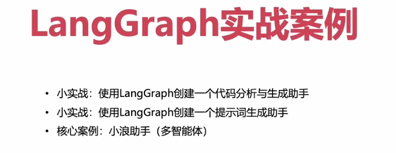

## 一、代码分析助手

- 针对特定问题参考材料迭代式的生成代码
- 从用户指定的一组文档开始
- 使用长上下文LLM 来提取它并执行 RAG来回答基于它的问题
- 调用一个工具来生成结构化输出
- 将解决方案返回给用户之前, 将执行两个单元测试 (检查导入和代码执行)

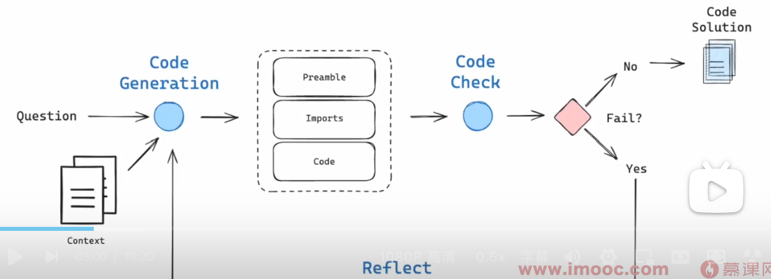


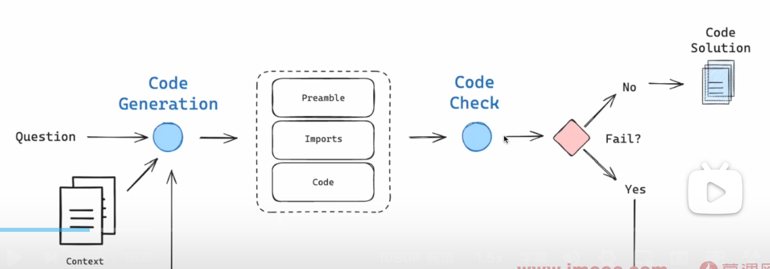
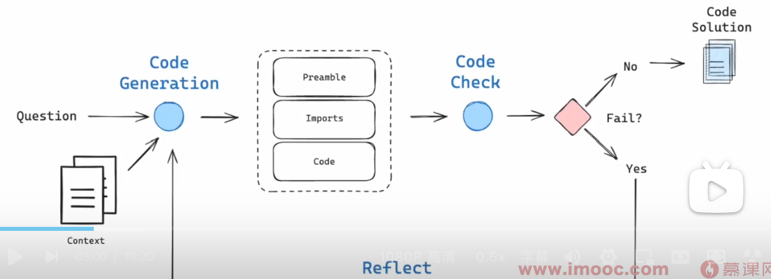

### 01.加载 LangGraph 文档

In [20]:
from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader


# langgraph docs
url = "https://github.langchain.ac.cn/langgraph/"

loader = RecursiveUrlLoader(
    url=url,
    max_depth=3,
    extractor=lambda x:Soup(x,"html.parser").text
)

docs = loader.load()

d_sorted = sorted(docs,key=lambda x:x.metadata["source"])
d_reversed = list(reversed(d_sorted))

concatenated_content = "\n\n\n --- \n\n\n".join([doc.page_content for doc in d_reversed])



In [21]:
concatenated_content

'\n\n\n\n\n\n\n\n\nLangGraph - LangChain 教程\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n跳到内容\n\n\n\n\n\n\n\n我们的 使用LangGraph构建环境智能体 课程现已在LangChain Academy上线！\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLangGraph\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n正在初始化搜索\n\n\n\n\n\n\n\n\n\n\n\nGitHub\n\n\n\n\n\n\n\n\n\nLangGraph\n\n\n智能体\n\n\nAPI 参考\n\n\n版本\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nGitHub\n\n\n\n\n\n\n\nLangGraph\n\n\n\n\n\n\n\n LangGraph\n\n\n\n\n 开始使用  \n\n\n 开始使用\n\n\n\n学习基础知识\n\n\n\n\n 部署  \n\n\n\n\n\n\n\n 指南  \n\n\n 指南\n\n\n\n 操作指南  \n\n\n\n 概念  \n\n\n\n 教程  \n\n\n\n\n\n\n\n 资源  \n\n\n 资源\n\n\n\n采用者\n\n\n\n\nLLMS-txt\n\n\n\n\n常见问题\n\n\n\n\n 故障排除  \n\n\n\nLangGraph 学院课程\n\n\n\n\n\n\n\n\n\n\n 智能体  \n\n\n\n API 参考  \n\n\n\n 版本  \n\n\n\n\n\n\n\n\n\n\n\n 目录\n\n\n\n全栈快速入门\n\n\n\n\n为何使用 LangGraph？\n\n\n\n\nLangGraph 的生态系统\n\n\n\n\n与 LangGraph 平台搭配使用\n\n\n\n\n更多资源\n\n\n\n\n致谢\n\n\n\n\n\n\n\n\n\n\n\n🦜🕸️LangGraph.js¶\n\n\n\n\n\n注意\n正在寻找 Python 版本？请参阅Pyt

In [30]:
from langchain_core.prompts import ChatPromptTemplate
from model_factory import MiniMax_Model
from pydantic import BaseModel, Field

code_gen_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """你是一位精通 LangGraph 的编程助手。

这里是 LangGraph 文档内容：
{context}

请根据上述文档回答用户问题。确保你提供的任何代码都可以执行，
包含所有必要的导入和已定义的变量。请按照以下结构组织回答：
首先描述代码解决方案，然后列出导入语句，最后给出功能完整的代码块。""",
        ),
        ("placeholder", "{messages}"),
    ]
)


class Code(BaseModel):
    """LangGraph 问题代码解决方式的模式"""

    prefix: str = Field(default="", description="问题和解决方案的描述")
    imports: str = Field(default="", description="代码块导入语句")
    code: str = Field(default="", description="不包含导入语句的代码块")


llm = MiniMax_Model

# include_raw=True 会返回 {"raw", "parsed", "parsing_error"}，方便检查解析错误。
code_gen_chain_oai = code_gen_prompt | llm.with_structured_output(Code, include_raw=True)


In [31]:
def check_output(tool_output):
    """
    检查 include_raw=True 的结构化输出，发现解析错误或未返回 parsed 时抛出异常。
    """
    if not isinstance(tool_output, dict):
        raise TypeError(
            f"期望结构化输出字典，但收到 {type(tool_output).__name__}。"
            "请确认链路使用了 llm.with_structured_output(Code, include_raw=True)。"
        )

    if tool_output.get("parsing_error"):
        raw = tool_output.get("raw")
        raw_output = getattr(raw, "content", raw)
        error = tool_output["parsing_error"]
        raise ValueError(f"解析错误: {error}\n原始输出: {raw_output}")

    if tool_output.get("parsed") is None:
        raise ValueError("模型没有返回符合 Code schema 的结构化结果")

    return tool_output


def insert_errors(inputs):
    """
    在消息中追加结构化输出解析错误，用于 fallback 重试。
    """
    error = inputs["error"]
    messages = inputs["messages"] + [
        (
            "assistant",
            f"重试。你需要修复结构化输出错误：{error}，并严格返回 Code schema。",
        )
    ]

    return {
        "messages": messages,
        "context": inputs["context"],
    }


def parse_output(solution):
    """
    返回最终的 Code 对象。

    - include_raw=True: solution 是包含 raw、parsed、parsing_error 的字典。
    - include_raw=False: solution 可能已经是 Code 对象。
    """
    if isinstance(solution, dict):
        return solution["parsed"]

    if isinstance(solution, Code):
        return solution

    raise TypeError(
        f"无法解析 {type(solution).__name__} 类型的输出。"
        "请不要把 code_gen_chain 定义成 code_gen_prompt | llm | parse_output。"
    )


code_chain_raw = code_gen_chain_oai | check_output
fallback_chain = insert_errors | code_chain_raw

N = 3
code_gen_chain = code_chain_raw.with_fallbacks(
    fallbacks=[fallback_chain] * N,
    exception_key="error",
) | parse_output


In [32]:
question = "如何构建一个 RAG 链"
solution = code_gen_chain.invoke(
    {
        "context": concatenated_content,
        "messages": [{"role": "user", "content": question}],
    }
)
solution


/opt/anaconda3/envs/ai/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Code(prefix='要构建一...rint(response.content)'), input_type=Code])
  return self.__pydantic_serializer__.to_python(


Code(prefix='要构建一个基本的 RAG (检索增强生成) 链，需要以下步骤：文档加载、分块、创建向量存储、定义检索和生成逻辑。\n\n以下是一个完整的 RAG 链实现：', imports='from langchain.text_splitter import RecursiveCharacterTextSplitter\nfrom langchain_core.documents import Document\nfrom langchain_openai import OpenAIEmbeddings\nfrom langchain.vectorstores import Chroma\nfrom langchain_core.prompts import ChatPromptTemplate\nfrom langchain_openai import ChatOpenAI\nfrom langchain import chain', code='from langchain.text_splitter import RecursiveCharacterTextSplitter\nfrom langchain_core.documents import Document\nfrom langchain_openai import OpenAIEmbeddings\nfrom langchain.vectorstores import Chroma\nfrom langchain_core.prompts import ChatPromptTemplate\nfrom langchain_openai import ChatOpenAI\n\n# 1. 创建文档\ndocuments = [\n    Document(\n        page_content="LangGraph 是一个用于构建有状态、多智能体应用程序的库。",\n        metadata={"source": "doc1"}\n    ),\n    Document(\n        page_content="RAG (检索增强生成) 是一种结合检索和生成的技术。",\n        metadata={"source": "doc2"}\n    )\n]\